# Competencia de Modelos: Prediccion de Clase de Material

**Objetivo**: Dado el `short_text` de un material, predecir a que `class` pertenece.

**Pipeline**:
1. Carga de datos desde archivos Excel (`data/xlsx/`)
2. Unificacion y cruce de fuentes (materiales + clases)
3. Analisis exploratorio del dataset
4. Preprocesamiento de texto
5. Split train/test estratificado
6. Entrenamiento de 4 modelos candidatos
7. Comparacion de metricas
8. Matriz de confusion del ganador
9. Exportacion del modelo ganador

## 1. Setup

In [ ]:
import os
import re
import glob
import warnings
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, top_k_accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

import joblib

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 80)

# Auto-detect environment: Docker vs local
if os.path.exists('/home/jovyan/work/data/xlsx'):
    DATA_DIR = '/home/jovyan/work/data/xlsx'
else:
    DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), 'data', 'xlsx')

print(f'DATA_DIR: {DATA_DIR}')
print('Imports OK')

## 2. Carga de Datos desde Excel

Detectamos automaticamente los 3 tipos de archivo:
- **Clases**: nombre contiene "clases" o "clase"
- **UNSPSC**: nombre contiene "unspsc" o "naciones"
- **Materiales**: todo lo demas (DIEN, ZCON, ZEQU, etc.)

In [2]:
# Auto-detectar archivos por tipo
all_files = glob.glob(os.path.join(DATA_DIR, '*.xlsx'))

classes_files = []
unspsc_files = []
material_files = []

for f in all_files:
    name = os.path.basename(f).lower()
    if 'clase' in name:
        classes_files.append(f)
    elif 'unspsc' in name or 'naciones' in name:
        unspsc_files.append(f)
    else:
        material_files.append(f)

print(f'Archivos detectados:')
print(f'  Clases:     {len(classes_files)} -> {[os.path.basename(f) for f in classes_files]}')
print(f'  UNSPSC:     {len(unspsc_files)} -> {[os.path.basename(f) for f in unspsc_files]}')
print(f'  Materiales: {len(material_files)} -> {[os.path.basename(f) for f in material_files]}')

Archivos detectados:
  Clases:     1 -> ['Clases de material DEN.xlsx']
  UNSPSC:     1 -> ['UNSPCS_NACIONES_UNIDAS.xlsx']
  Materiales: 13 -> ['ZCON_29MAY26.xlsx', 'ZQUI_29MAY26.xlsx', 'ZMAQ_29MAY26.xlsx', 'ZEQU_29MAY26.xlsx', 'ZRPA_29MAY26.xlsx', 'ZSEG_29MAY26.xlsx', 'DIEN_29MAY26.xlsx', 'ZMER MOB OFI VEH TUB_29MAY26.xlsx', 'ZMAF_29MAY26.xlsx', 'ZRPI_29MAY26.xlsx', 'ZHAR_29MAY26.xlsx', 'ZSUM_29MAY26.xlsx', 'ZHER_29MAY26.xlsx']


In [3]:
def _to_str(val):
    """Convertir valor a string limpio (sin .0 de float)."""
    if val is None or pd.isna(val):
        return None
    if isinstance(val, float) and val == int(val):
        return str(int(val))
    return str(val).strip()

def _extract_code(val):
    """Extraer codigo antes de ' - ' (e.g. 'ZCON - Materiales' -> 'ZCON')."""
    if val is None or pd.isna(val):
        return None
    s = str(val).strip()
    if ' - ' in s:
        return s.split(' - ')[0].strip()
    return s

def _prefix_rename(df, col_map):
    """Renombrar columnas usando prefix matching (solo la primera coincidencia por destino)."""
    rename = {}
    used_dsts = set()
    for col in df.columns:
        for src, dst in col_map.items():
            if dst in used_dsts:
                continue
            if col == src or col.startswith(src):
                rename[col] = dst
                used_dsts.add(dst)
                break
    return df.rename(columns=rename)

In [4]:
# --- Cargar clases ---
CLASS_COLS = {
    'Código': 'class_code',
    'Denominación': 'class_name',
    'Grupo de Artículos': 'article_group',
    'Sector': 'sector',
    'Tipo de Material': 'material_type',
    'UNSPSC': 'unspsc',
}

dfs_classes = []
for f in classes_files:
    df_c = pd.read_excel(f, dtype=str, engine='openpyxl')
    df_c = _prefix_rename(df_c, CLASS_COLS)
    dfs_classes.append(df_c)

df_classes = pd.concat(dfs_classes, ignore_index=True)
df_classes['class_code'] = df_classes['class_code'].apply(_to_str)
if 'material_type' in df_classes.columns:
    df_classes['material_type'] = df_classes['material_type'].apply(_extract_code)
df_classes = df_classes.dropna(subset=['class_code', 'class_name']).drop_duplicates(subset=['class_code'])

print(f'Clases cargadas: {len(df_classes):,}')
df_classes.head()

Clases cargadas: 1,538


,class_code,class_name,article_group,sector,material_type,unspsc,ID
0,053111,PINTURAS:DECORATIVAS,ART371000 - Obras de arte,50 - Otros,ZART,60121001 - Pinturas,6740
1,010535,GRIFO,CON251100 - Artefactos Sanitario,50 - Otros,ZCON,30181700 - Grifos.,6741
2,010648,DUCHA DE BAÑO,CON251100 - Artefactos Sanitario,50 - Otros,ZCON,30181801 - Pomo de ducha,6742
3,015238,DEPOSITO,CON251000 - Accesorios,50 - Otros,ZCON,24111810 - Tanques de almacenamiento agua,6743
4,015567,ARENA:CONSTRUCCION,SUM231200 - Consumibles,50 - Otros,ZCON,11111701 - Arena de sílice,6744


In [5]:
# --- Cargar materiales (multiples archivos) ---
MATERIAL_COLS = {
    'Material': 'material_code',
    'Unidad medida base': 'uom',
    'Denom.estándar': 'class_code',
    'Texto breve de material': 'short_text',
}

dfs_materials = []
for f in material_files:
    df_m = pd.read_excel(f, dtype=str, engine='openpyxl')
    # pandas auto-deduplicates columns (e.g. "Texto breve de material.1")
    # so we just use prefix rename which only takes the first match per destination
    df_m = _prefix_rename(df_m, MATERIAL_COLS)
    # Keep only needed columns
    keep = [c for c in ['material_code', 'class_code', 'short_text'] if c in df_m.columns]
    df_m = df_m[keep].copy()
    df_m['source_file'] = os.path.basename(f)
    dfs_materials.append(df_m)
    print(f'  {os.path.basename(f)}: {len(df_m):,} filas')

df_materials = pd.concat(dfs_materials, ignore_index=True)
df_materials['material_code'] = df_materials['material_code'].apply(_to_str)
df_materials['class_code'] = df_materials['class_code'].apply(_to_str)
df_materials = df_materials.dropna(subset=['material_code', 'short_text'])

print(f'\nTotal materiales cargados: {len(df_materials):,}')
print(f'Columnas: {list(df_materials.columns)}')

  ZCON_29MAY26.xlsx: 1,692 filas
  ZQUI_29MAY26.xlsx: 5,667 filas
  ZMAQ_29MAY26.xlsx: 93 filas
  ZEQU_29MAY26.xlsx: 145 filas
  ZRPA_29MAY26.xlsx: 337 filas
  ZSEG_29MAY26.xlsx: 2,626 filas
  DIEN_29MAY26.xlsx: 531 filas
  ZMER MOB OFI VEH TUB_29MAY26.xlsx: 2,552 filas
  ZMAF_29MAY26.xlsx: 80 filas
  ZRPI_29MAY26.xlsx: 15,861 filas
  ZHAR_29MAY26.xlsx: 384 filas
  ZSUM_29MAY26.xlsx: 13,399 filas
  ZHER_29MAY26.xlsx: 2,033 filas

Total materiales cargados: 45,397
Columnas: ['material_code', 'class_code', 'short_text', 'source_file']


In [6]:
# --- Cruzar materiales con clases ---
df = df_materials.merge(
    df_classes[['class_code', 'class_name', 'material_type']],
    on='class_code',
    how='inner'
)

# Drop any duplicate columns that survived
df = df.loc[:, ~df.columns.duplicated()]

no_class = len(df_materials) - len(df)
print(f'Materiales con clase asignada: {len(df):,}')
print(f'Materiales sin clase (descartados): {no_class:,}')
print(f'Clases unicas: {df["class_code"].nunique()}')
print(f'Tipos de material: {df["material_type"].nunique()}')
print(f'Columnas: {list(df.columns)}')
df.head()

Materiales con clase asignada: 40,029
Materiales sin clase (descartados): 5,368
Clases unicas: 1529
Tipos de material: 17
Columnas: ['material_code', 'class_code', 'short_text', 'source_file', 'class_name', 'material_type']


,material_code,class_code,short_text,source_file,class_name,material_type
0,11001918,088014,MALLA ELECTROSOLDADA 1.22M,ZCON_29MAY26.xlsx,MALLA,ZSEG
1,11001919,088014,MALLA:CICLON;4FT,ZCON_29MAY26.xlsx,MALLA,ZSEG
2,11001920,088014,MALLA:CICLON;6FT,ZCON_29MAY26.xlsx,MALLA,ZSEG
3,11001921,088014,"MALLA:P/COLAR;ARENA;1/4""X48""",ZCON_29MAY26.xlsx,MALLA,ZSEG
4,11001923,088014,MALLA;ELECTROSOLDADA;#2,ZCON_29MAY26.xlsx,MALLA,ZSEG


## 3. Analisis Exploratorio

In [7]:
# Distribucion de materiales por clase
class_counts = df['class_code'].value_counts()

print(f'Clase con mas materiales: {class_counts.index[0]} ({class_counts.iloc[0]:,} materiales)')
print(f'Clase con menos materiales: {class_counts.index[-1]} ({class_counts.iloc[-1]} materiales)')
print(f'Mediana de materiales por clase: {class_counts.median():.0f}')
print(f'\nDistribucion de tamaño de clases:')
print(f'  Clases con 1 material: {(class_counts == 1).sum()}')
print(f'  Clases con 2-10: {((class_counts >= 2) & (class_counts <= 10)).sum()}')
print(f'  Clases con 11-50: {((class_counts > 10) & (class_counts <= 50)).sum()}')
print(f'  Clases con 51-100: {((class_counts > 50) & (class_counts <= 100)).sum()}')
print(f'  Clases con 100+: {(class_counts > 100).sum()}')

Clase con mas materiales: 081946 (655 materiales)
Clase con menos materiales: 044556 (1 materiales)
Mediana de materiales por clase: 9

Distribucion de tamaño de clases:
  Clases con 1 material: 132
  Clases con 2-10: 697
  Clases con 11-50: 517
  Clases con 51-100: 103
  Clases con 100+: 80


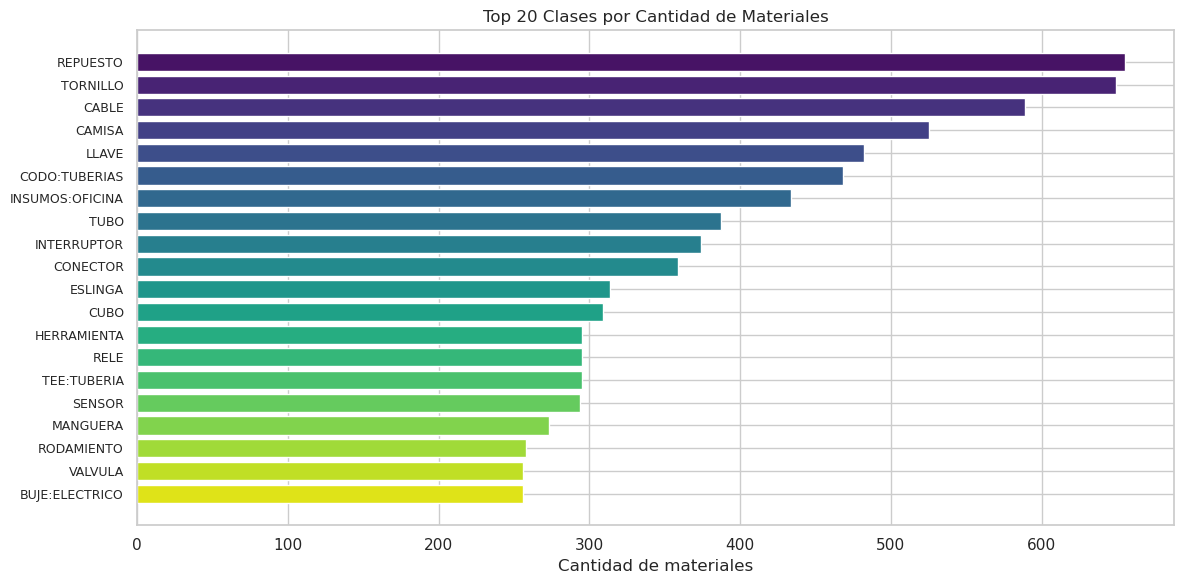

In [8]:
# Top 20 clases por cantidad de materiales
fig, ax = plt.subplots(figsize=(12, 6))
top20 = class_counts.head(20)
name_map = df.drop_duplicates('class_code').set_index('class_code')['class_name']
labels = [f'{name_map.get(c, c)}' for c in top20.index]
ax.barh(range(len(top20)), top20.values, color=sns.color_palette('viridis', len(top20)))
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Cantidad de materiales')
ax.set_title('Top 20 Clases por Cantidad de Materiales')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

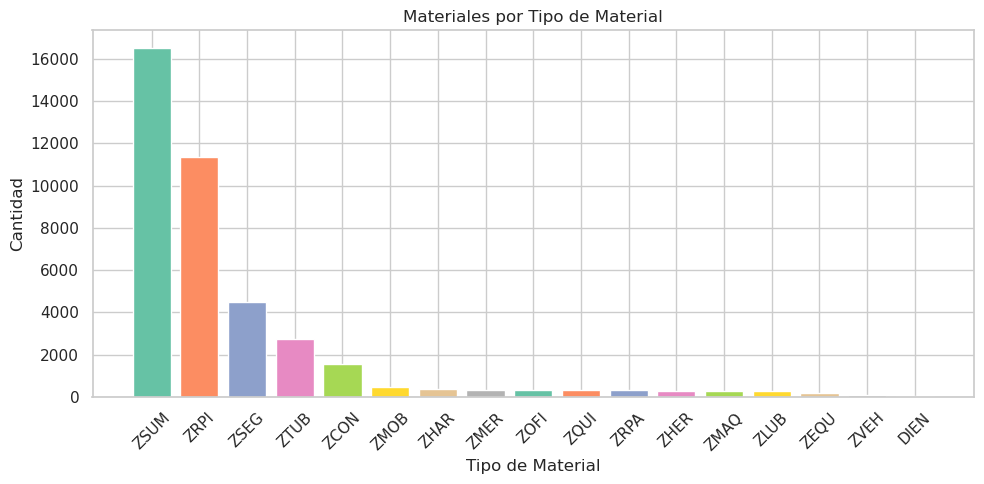

In [9]:
# Distribucion por tipo de material
fig, ax = plt.subplots(figsize=(10, 5))
type_counts = df['material_type'].value_counts()
ax.bar(type_counts.index, type_counts.values, color=sns.color_palette('Set2', len(type_counts)))
ax.set_xlabel('Tipo de Material')
ax.set_ylabel('Cantidad')
ax.set_title('Materiales por Tipo de Material')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

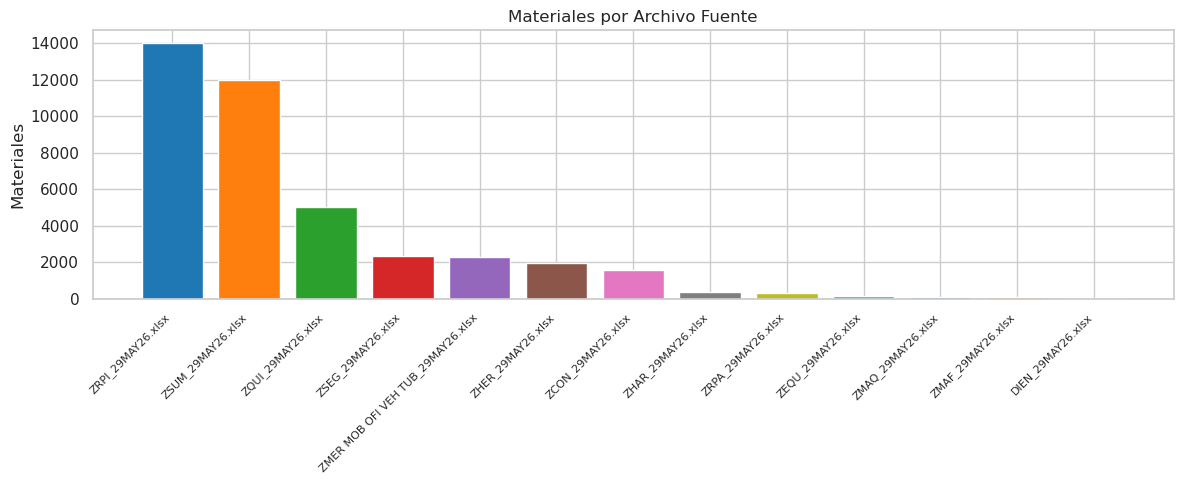

In [10]:
# Distribucion por archivo fuente
fig, ax = plt.subplots(figsize=(12, 5))
src_counts = df['source_file'].value_counts()
ax.bar(range(len(src_counts)), src_counts.values, color=sns.color_palette('tab10', len(src_counts)))
ax.set_xticks(range(len(src_counts)))
ax.set_xticklabels(src_counts.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Materiales')
ax.set_title('Materiales por Archivo Fuente')
plt.tight_layout()
plt.show()

Estadisticas del short_text:
       text_len  token_count  semicolons
count   40029.0      40029.0     40029.0
mean       32.3          4.9         2.3
std         7.3          1.4         1.5
min         1.0          1.0         0.0
25%        28.0          4.0         1.0
50%        34.0          5.0         2.0
75%        39.0          6.0         3.0
max        40.0         12.0         8.0


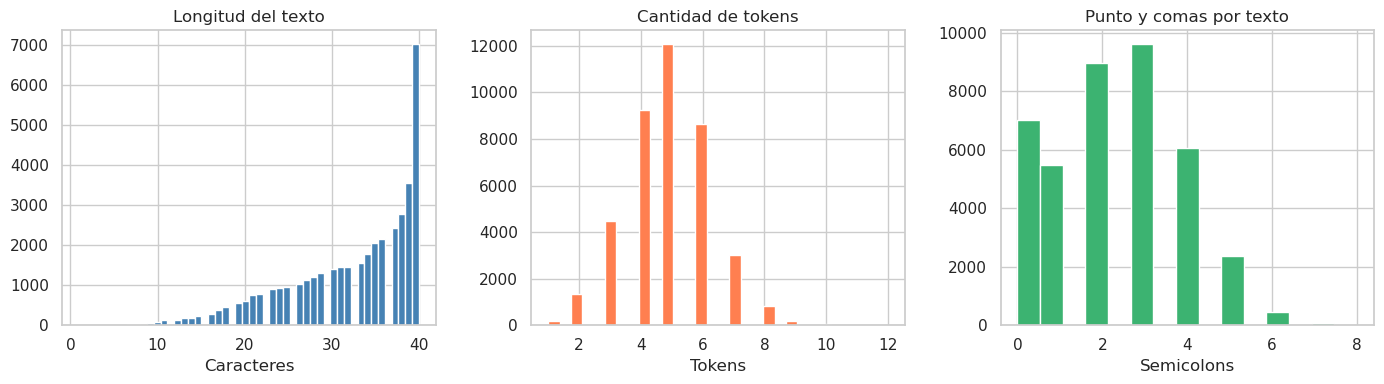

In [11]:
# Analisis del short_text
df['text_len'] = df['short_text'].str.len()
df['token_count'] = df['short_text'].str.split(r'[;:\s]+').apply(len)
df['semicolons'] = df['short_text'].str.count(';')

print('Estadisticas del short_text:')
print(df[['text_len', 'token_count', 'semicolons']].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(df['text_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Longitud del texto')
axes[0].set_xlabel('Caracteres')
axes[1].hist(df['token_count'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Cantidad de tokens')
axes[1].set_xlabel('Tokens')
axes[2].hist(df['semicolons'], bins=15, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Punto y comas por texto')
axes[2].set_xlabel('Semicolons')
plt.tight_layout()
plt.show()

## 4. Preprocesamiento de Texto

In [12]:
def preprocess_text(text: str) -> str:
    """Normalizar texto SAP para clasificacion."""
    text = text.upper()
    text = unicodedata.normalize('NFD', text)
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')
    text = re.sub(r'[;:,/\\|]+', ' ', text)
    text = re.sub(r'[^A-Z0-9.\-\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['short_text'].apply(preprocess_text)

# Mostrar antes/despues
sample = df[['short_text', 'clean_text']].sample(5, random_state=42)
for _, row in sample.iterrows():
    print(f'ANTES:   {row["short_text"]}')
    print(f'DESPUES: {row["clean_text"]}')
    print()

ANTES:   CADENA:SEGURIDAD;1/4";P/LAMPARA
DESPUES: CADENA SEGURIDAD 1 4 P LAMPARA

ANTES:   RECIPI:VIDRIO P/MUETSRA DE ACEITE;16 OZ
DESPUES: RECIPI VIDRIO P MUETSRA DE ACEITE 16 OZ

ANTES:   ANCLAJE;MULTIPLICADOR;3 PUNTOS;3MM
DESPUES: ANCLAJE MULTIPLICADOR 3 PUNTOS 3MM

ANTES:   TEE:TUBERIA;3";LISO A/P;PVC
DESPUES: TEE TUBERIA 3 LISO A P PVC

ANTES:   TUERCA HEXAGONAL; 3/4";RO;G-8;HN
DESPUES: TUERCA HEXAGONAL 3 4 RO G-8 HN



## 5. Filtrado y Split Train/Test

In [13]:
# Filtrar clases con muy pocos ejemplos (minimo 3 para estratificar)
MIN_SAMPLES = 3
class_counts_clean = df['class_code'].value_counts()
valid_classes = class_counts_clean[class_counts_clean >= MIN_SAMPLES].index
df_model = df[df['class_code'].isin(valid_classes)].copy()

removed = len(df) - len(df_model)
print(f'Materiales removidos (clases con <{MIN_SAMPLES} ejemplos): {removed:,}')
print(f'Dataset final: {len(df_model):,} materiales, {df_model["class_code"].nunique()} clases')

Materiales removidos (clases con <3 ejemplos): 458
Dataset final: 39,571 materiales, 1234 clases


In [14]:
# Encode labels
le = LabelEncoder()
df_model['label'] = le.fit_transform(df_model['class_code'])

X = df_model['clean_text'].values
y = df_model['label'].values

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} materiales')
print(f'Test:  {len(X_test):,} materiales')
print(f'Clases: {len(le.classes_)}')

Train: 31,656 materiales
Test:  7,915 materiales
Clases: 1234


## 6. Definicion de Modelos Candidatos

In [15]:
candidates = {
    'LogReg + CharTFIDF': Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2, 5),
            max_features=50000, sublinear_tf=True, strip_accents='unicode')),
        ('clf', LogisticRegression(
            max_iter=1000, C=5.0, solver='saga', n_jobs=-1)),
    ]),
    'LogReg + WordTFIDF': Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2),
            max_features=30000, sublinear_tf=True, strip_accents='unicode')),
        ('clf', LogisticRegression(
            max_iter=1000, C=5.0, solver='saga', n_jobs=-1)),
    ]),
    'LinearSVC + CharTFIDF': Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='char_wb', ngram_range=(2, 5),
            max_features=50000, sublinear_tf=True, strip_accents='unicode')),
        ('clf', CalibratedClassifierCV(
            LinearSVC(max_iter=2000, C=1.0), cv=3)),
    ]),
    'RandomForest + WordTFIDF': Pipeline([
        ('tfidf', TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2),
            max_features=30000, sublinear_tf=True, strip_accents='unicode')),
        ('clf', RandomForestClassifier(
            n_estimators=300, max_depth=None, n_jobs=-1, random_state=42)),
    ]),
}

print(f'{len(candidates)} modelos candidatos definidos')
for name in candidates:
    print(f'  - {name}')

4 modelos candidatos definidos
  - LogReg + CharTFIDF
  - LogReg + WordTFIDF
  - LinearSVC + CharTFIDF
  - RandomForest + WordTFIDF


## 7. Entrenamiento y Evaluacion

In [ ]:
import time

results = {}

for name, pipeline in candidates.items():
    print(f'\n{"="*60}')
    print(f'Entrenando: {name}')
    print(f'{"="*60}')

    t0 = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)

    top3_acc = None
    if hasattr(pipeline, 'predict_proba'):
        y_proba = pipeline.predict_proba(X_test)
        k = min(3, y_proba.shape[1])
        top3_acc = top_k_accuracy_score(y_test, y_proba, k=k, labels=range(y_proba.shape[1]))

    results[name] = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_weighted': prec_weighted,
        'recall_weighted': rec_weighted,
        'top3_accuracy': top3_acc,
        'train_time': train_time,
        'pipeline': pipeline,
        'y_pred': y_pred,
    }

    print(f'  Accuracy:         {acc:.4f}')
    print(f'  F1 (macro):       {f1_macro:.4f}')
    print(f'  F1 (weighted):    {f1_weighted:.4f}')
    print(f'  Precision (w):    {prec_weighted:.4f}')
    print(f'  Recall (w):       {rec_weighted:.4f}')
    if top3_acc is not None:
        print(f'  Top-3 Accuracy:   {top3_acc:.4f}')
    print(f'  Tiempo:           {train_time:.1f}s')

print(f'\nEntrenamiento completo.')


Entrenando: LogReg + CharTFIDF


## 8. Comparacion de Modelos

In [ ]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'F1 Macro': r['f1_macro'],
        'F1 Weighted': r['f1_weighted'],
        'Precision': r['precision_weighted'],
        'Recall': r['recall_weighted'],
        'Top-3 Acc': r['top3_accuracy'] if r['top3_accuracy'] else float('nan'),
        'Tiempo (s)': r['train_time'],
    }
    for name, r in results.items()
}).T

comparison_styled = comparison.style.highlight_max(
    axis=0, subset=['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision', 'Recall', 'Top-3 Acc'],
    color='lightgreen'
).format('{:.4f}')
comparison_styled

In [ ]:
# Grafico comparativo
metrics_to_plot = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision', 'Recall']
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_to_plot))
width = 0.18
colors = sns.color_palette('Set2', len(results))

for i, (name, r) in enumerate(results.items()):
    vals = [comparison.loc[name, m] for m in metrics_to_plot]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i])

ax.set_xticks(x + width * (len(results) - 1) / 2)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparacion de Modelos')
ax.legend(loc='lower right')
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Seleccion del Ganador

In [ ]:
winner_name = comparison['F1 Weighted'].idxmax()
winner = results[winner_name]

print(f'MODELO GANADOR: {winner_name}')
print(f'  Accuracy:      {winner["accuracy"]:.4f}')
print(f'  F1 Weighted:   {winner["f1_weighted"]:.4f}')
print(f'  F1 Macro:      {winner["f1_macro"]:.4f}')
if winner['top3_accuracy']:
    print(f'  Top-3 Acc:     {winner["top3_accuracy"]:.4f}')
print(f'  Tiempo:        {winner["train_time"]:.1f}s')

## 10. Matriz de Confusion del Ganador

In [ ]:
# Matriz de confusion - top N clases mas frecuentes
TOP_N = 20
top_classes = df_model['label'].value_counts().head(TOP_N).index.tolist()

mask = np.isin(y_test, top_classes)
y_test_top = y_test[mask]
y_pred_top = winner['y_pred'][mask]

cm = confusion_matrix(y_test_top, y_pred_top, labels=top_classes)

class_code_map = df_model.drop_duplicates('label').set_index('label')['class_name'].to_dict()
top_labels = [class_code_map.get(c, str(c))[:25] for c in top_classes]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=top_labels, yticklabels=top_labels,
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Prediccion')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusion - Top {TOP_N} Clases ({winner_name})')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
report = classification_report(
    y_test_top, y_pred_top,
    labels=top_classes,
    target_names=top_labels,
    zero_division=0
)
print(f'Classification Report - Top {TOP_N} Clases ({winner_name})')
print(report)

## 11. Analisis de Confianza

In [ ]:
if hasattr(winner['pipeline'], 'predict_proba'):
    y_proba = winner['pipeline'].predict_proba(X_test)
    confidences = y_proba.max(axis=1)
    correct = (winner['y_pred'] == y_test)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(confidences[correct], bins=50, alpha=0.7, label='Correctas', color='green')
    axes[0].hist(confidences[~correct], bins=50, alpha=0.7, label='Incorrectas', color='red')
    axes[0].set_xlabel('Confianza')
    axes[0].set_ylabel('Frecuencia')
    axes[0].set_title('Distribucion de Confianza')
    axes[0].legend()

    thresholds = np.arange(0.1, 1.0, 0.05)
    accs = []
    coverages = []
    for t in thresholds:
        mask = confidences >= t
        if mask.sum() > 0:
            accs.append(accuracy_score(y_test[mask], winner['y_pred'][mask]))
            coverages.append(mask.mean())
        else:
            accs.append(float('nan'))
            coverages.append(0)

    ax2 = axes[1]
    ax2.plot(thresholds, accs, 'b-o', markersize=4, label='Accuracy')
    ax2.set_xlabel('Umbral de Confianza')
    ax2.set_ylabel('Accuracy', color='b')
    ax2_twin = ax2.twinx()
    ax2_twin.plot(thresholds, coverages, 'r--s', markersize=4, label='Cobertura')
    ax2_twin.set_ylabel('Cobertura', color='r')
    ax2.set_title('Accuracy vs Cobertura por Umbral')
    ax2.legend(loc='lower left')
    ax2_twin.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

    print(f'\nResumen de umbrales de confianza:')
    for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
        mask = confidences >= t
        if mask.sum() > 0:
            acc = accuracy_score(y_test[mask], winner['y_pred'][mask])
            print(f'  Umbral {t:.1f}: accuracy={acc:.4f}, cobertura={mask.mean():.2%} ({mask.sum():,} materiales)')
else:
    print('El modelo ganador no soporta predict_proba')

## 12. Analisis de Errores

In [ ]:
errors_mask = winner['y_pred'] != y_test
error_pairs = pd.DataFrame({
    'real': y_test[errors_mask],
    'pred': winner['y_pred'][errors_mask],
    'text': X_test[errors_mask],
})

print(f'Total errores: {len(error_pairs):,} de {len(y_test):,} ({len(error_pairs)/len(y_test):.2%})')
print(f'\nTop 10 confusiones mas frecuentes:')

top_confusions = error_pairs.groupby(['real', 'pred']).size().sort_values(ascending=False).head(10)
for (real, pred), count in top_confusions.items():
    real_name = class_code_map.get(real, str(real))
    pred_name = class_code_map.get(pred, str(pred))
    print(f'  {real_name[:30]:30s} -> {pred_name[:30]:30s} ({count} errores)')

In [ ]:
print('Ejemplos de predicciones incorrectas:')
print('=' * 100)
sample_errors = error_pairs.sample(min(10, len(error_pairs)), random_state=42)
for _, row in sample_errors.iterrows():
    real_name = class_code_map.get(row['real'], str(row['real']))
    pred_name = class_code_map.get(row['pred'], str(row['pred']))
    print(f'  Texto:     {row["text"]}')
    print(f'  Real:      {real_name}')
    print(f'  Predicho:  {pred_name}')
    print()

## 13. Conclusion y Exportacion

In [ ]:
print('=' * 60)
print('RESUMEN DE LA COMPETENCIA')
print('=' * 60)
print(f'\nDataset: {len(df_model):,} materiales, {df_model["class_code"].nunique()} clases')
print(f'Fuente: {len(material_files)} archivos Excel de materiales')
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'\nResultados:')
print(comparison.to_string())
print(f'\nGANADOR: {winner_name}')
print(f'  Accuracy:      {winner["accuracy"]:.4f}')
print(f'  F1 Weighted:   {winner["f1_weighted"]:.4f}')

In [ ]:
# Reentrenar el ganador con TODOS los datos para produccion
print(f'Reentrenando {winner_name} con dataset completo ({len(df_model):,} materiales)...')

X_full = df_model['clean_text'].values
y_full = df_model['label'].values

winner['pipeline'].fit(X_full, y_full)
print('Entrenamiento completo.')

# Construir mapeo label -> class_code
label_to_class = df_model.drop_duplicates('label').set_index('label')['class_code'].to_dict()

# Exportar modelo + label encoder + metadata
artifact = {
    'pipeline': winner['pipeline'],
    'label_encoder': le,
    'model_name': winner_name,
    'n_classes': len(le.classes_),
    'n_samples': len(X_full),
    'metrics': {
        'accuracy': winner['accuracy'],
        'f1_weighted': winner['f1_weighted'],
        'f1_macro': winner['f1_macro'],
        'top3_accuracy': winner['top3_accuracy'],
    },
    'label_to_class_code': {int(k): str(v) for k, v in label_to_class.items()},
}

output_path = '/home/jovyan/work/data/model_artifact.joblib'
joblib.dump(artifact, output_path)
print(f'\nModelo exportado a: {output_path}')
print(f'Tamaño: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB')